# TT-18 — 01. Kham pha & lam sach du lieu
Ames Housing — thiet lap missing-value handling, ma hoa thu tu, va kiem tra do lech nhan.

**Yeu cau du lieu:** dat file `train.csv` cua bo Kaggle *House Prices - Advanced Regression Techniques* vao thu muc `../data/` truoc khi chay notebook nay (xem README.md).

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import features as feat

pd.set_option('display.max_columns', 50)
DATA_PATH = '../data/train.csv'

## 1. Doc du lieu

In [2]:
df_raw = feat.load_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(1460, 34)


,Id,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,YrSold,1stFlrSF,2ndFlrSF,TotalBsmtSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,Neighborhood,HouseStyle,RoofStyle,SaleCondition,ExterQual,ExterCond,HeatingQC,KitchenQual,BsmtQual,GarageQual,FireplaceQu,PoolQC,Alley,LotFrontage,MasVnrArea,SalePrice
0,259,5978,5,2,1967,1990,2006,660,0,2198,636,2,1,2,6,2,1,205,NWAmes,1.5Fin,Hip,Normal,TA,Gd,TA,Gd,Gd,TA,TA,NaN,NaN,79.633235,200.0,533800.0
1,268,8896,6,4,1908,1931,2007,656,0,295,628,1,1,4,8,2,0,0,NAmes,SLvl,Flat,Normal,TA,TA,Ex,TA,Ex,NaN,TA,NaN,NaN,NaN,0.0,567400.0
2,289,12218,9,4,1980,1989,2006,1262,0,1577,1231,2,0,3,6,0,2,548,CollgCr,SLvl,Gable,Normal,TA,Ex,TA,TA,TA,TA,NaN,NaN,NaN,86.277801,0.0,979200.0
3,650,17425,3,3,1925,1928,2006,681,531,918,1214,1,1,2,4,0,3,636,NAmes,1.5Fin,Hip,Normal,Gd,TA,Gd,Gd,Gd,Ex,NaN,NaN,NaN,56.488096,200.0,458700.0
4,1234,15749,5,9,1936,1942,2008,753,0,1946,771,3,0,2,5,2,0,0,NAmes,SFoyer,Gable,Normal,Gd,TA,Ex,Ex,Fa,NaN,TA,NaN,NaN,61.596510,0.0,888000.0


## 2. Thong ke & phan loai gia tri thieu
Phan biet **'khong co tien ich'** (NaN co y nghia — vd `PoolQC=NaN` nghia la nha khong co be boi) voi **'thieu that'** (can dien median/mode).

In [3]:
report = feat.missing_value_report(df_raw)
report

,cot,so_dong_thieu,ty_le_%,phan_loai
0,PoolQC,1451,99.4,khong_co_tien_ich (NaN co y nghia)
1,Alley,1364,93.4,khong_co_tien_ich (NaN co y nghia)
2,FireplaceQu,474,32.5,khong_co_tien_ich (NaN co y nghia)
3,GarageQual,419,28.7,khong_co_tien_ich (NaN co y nghia)
4,LotFrontage,236,16.2,thieu_that (se dien median)
5,MasVnrArea,6,0.4,khong_co_tien_ich (NaN co y nghia)


So cot 'khong co tien ich' (NaN co y nghia): 5
So cot 'thieu that' (se dien median/mode):   1


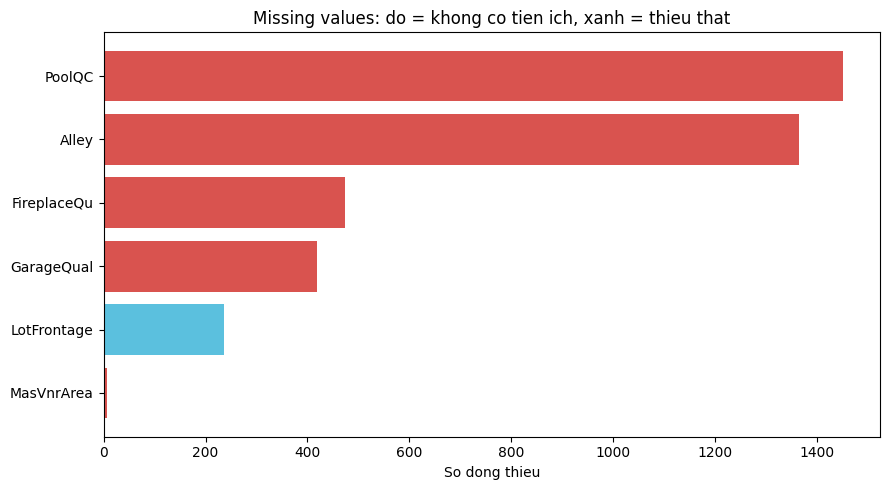

In [4]:
n_none = report['phan_loai'].str.contains('khong_co_tien_ich').sum()
n_true = len(report) - n_none
print(f"So cot 'khong co tien ich' (NaN co y nghia): {n_none}")
print(f"So cot 'thieu that' (se dien median/mode):   {n_true}")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d9534f' if 'khong_co_tien_ich' in c else '#5bc0de' for c in report['phan_loai']]
ax.barh(report['cot'], report['so_dong_thieu'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('So dong thieu')
ax.set_title("Missing values: do = khong co tien ich, xanh = thieu that")
fig.tight_layout()
fig.savefig('../reports/missing_analysis.png', dpi=130)
plt.show()

## 3. Xu ly gia tri thieu (khong xoa cot, khong xoa dong)

In [5]:
df_clean = feat.handle_missing(df_raw)
assert df_clean.isna().sum().sum() == 0, 'Van con gia tri thieu!'
print('Da xu ly xong. Con lai NaN:', df_clean.isna().sum().sum())
print('So cot khong doi (khong cot nao bi xoa):', df_clean.shape[1] == df_raw.shape[1])

Da xu ly xong. Con lai NaN: 0
So cot khong doi (khong cot nao bi xoa): True


## 4. Bien thu tu (Ordinal) va bien danh muc (Nominal)
Cac cot chat luong (`ExterQual`, `KitchenQual`, `BsmtQual`, ...) co thu tu ro rang `Po < Fa < TA < Gd < Ex`, nen duoc ma hoa bang `OrdinalEncoder` dung thu tu — khong dung one-hot vi se lam mat thong tin thu bac.

In [6]:
df_fe = feat.engineer_features(df_clean)
preprocessor, (num_cols, ord_cols, nom_cols) = feat.build_preprocessor(df_fe)
print(f'{len(ord_cols)} cot ordinal:', ord_cols)
print(f'{len(nom_cols)} cot nominal (one-hot):', nom_cols[:10], '...')
print(f'{len(num_cols)} cot numeric')

8 cot ordinal: ['ExterQual', 'ExterCond', 'BsmtQual', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'PoolQC']
5 cot nominal (one-hot): ['Neighborhood', 'HouseStyle', 'RoofStyle', 'SaleCondition', 'Alley'] ...
22 cot numeric


## 5. Do lech nhan SalePrice → log1p
Vai can nha sieu dat lam nhan lech phai manh. Dung `log1p(SalePrice)` de huan luyen, va `expm1()` de doi nguoc khi bao cao gia du doan.

Skew(SalePrice)        = 1.792
Skew(log1p(SalePrice)) = 0.252


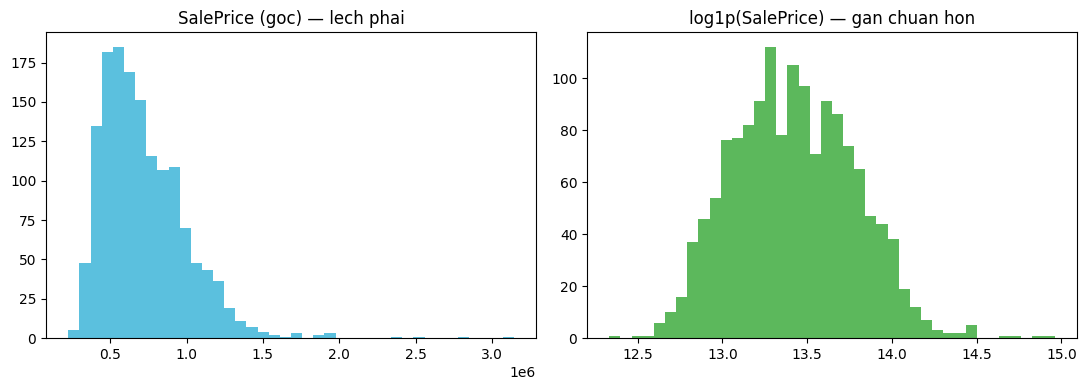

In [7]:
sale_price = df_fe['SalePrice']
log_price = np.log1p(sale_price)
print(f"Skew(SalePrice)        = {skew(sale_price):.3f}")
print(f"Skew(log1p(SalePrice)) = {skew(log_price):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sale_price, bins=40, color='#5bc0de')
axes[0].set_title('SalePrice (goc) — lech phai')
axes[1].hist(log_price, bins=40, color='#5cb85c')
axes[1].set_title('log1p(SalePrice) — gan chuan hon')
fig.tight_layout()
plt.show()

## 6. Feature engineering
`TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`, `TuoiNha = YrSold - YearBuilt`, `DaSuaChua = (YearRemodAdd != YearBuilt)` — hieu qua cua cac dac trung nay duoc danh gia (RMSE truoc/sau) trong notebook `02_gbr_model.ipynb`.

In [8]:
df_fe[['TotalSF', 'TuoiNha', 'DaSuaChua']].describe()

,TotalSF,TuoiNha,DaSuaChua
count,1460.000000,1460.000000,1460.000000
mean,2983.126027,53.908904,0.963699
std,1070.891802,31.416795,0.187103
min,471.000000,0.000000,0.000000
25%,2234.000000,27.000000,1.000000
50%,2953.000000,54.000000,1.000000
75%,3712.500000,81.000000,1.000000
max,6132.000000,110.000000,1.000000


Du lieu da lam sach (`df_fe`) va bo tien xu ly (`preprocessor`) san sang cho buoc huan luyen mo hinh trong `02_gbr_model.ipynb`.